# RefugeeMatch — Predicting Monthly Expense Affordability

**Objective:** Build a classification model that predicts whether a refugee will be able to afford their monthly living expenses, using only features that a caseworker can collect at intake.
**Dataset:** 2022 Annual Survey of Refugees (ASR) — respondents only
**Target:** `qn58` — "Was your family able to pay its monthly living expenses last month?" (binary: Yes/No)
**Author:** Abbot Tubeine & Harrison Hershberger, Sattler College

---

## Pipeline Overview

1. **Data Cleaning** — handle missing values, encode categoricals, exclude post-arrival features
2. **Fairness Filter** — drop country of birth and sex (protected demographics) before any modeling
3. **Pre-Training Data Analysis** — distributions, bivariate target rates, multicollinearity
4. **Statistical Feature Filter** — keep only features with measurable predictive signal in this dataset
5. **Train/Test Split** — stratified 80/20 split
6. **Model Training** — Logistic Regression (chosen for monotonic, explainable attributions)
7. **Calibration & Threshold Tuning**
8. **Evaluation & Export**

## Critical Design Constraints

**Deployment constraint:** The model is trained on post-resettlement survey data but is intended to be used at intake — before refugees have jobs, rent, or U.S. experience. We therefore exclude all post-arrival features (income, rent, employment status, English now, benefits receipt) from training.

**Fairness constraint:** We exclude country of birth (proxy for ethnicity/religion) and sex from training, even though they have some statistical signal. Resettlement decisions should not be differentiated by these protected characteristics.

**Explainability constraint:** With only 1,400 rows and 161 positive cases, tree models (Random Forest, XGBoost) overfit to local noise — producing attributions that contradict the underlying data direction (e.g., "advanced degree increases risk" when education is the strongest negative correlate). Logistic Regression is monotonic by construction: if a feature has a negative coefficient, increasing it always lowers predicted risk. For a tool that caseworkers must defend, structural monotonicity matters more than a marginal AUC gain.

**Statistical signal constraint:** We retain only features that demonstrate measurable predictive signal in this dataset (chi-squared p < 0.10 AND |correlation| > 0.05 OR strong domain justification). Features with no statistical signal contribute only noise to attributions, which is the worst outcome for an explainable tool.

## Final feature set (5 features)

| Feature | Source | Justification |
|---|---|---|
| `education_pre_arrival` | Asked at intake | Strongest predictor (r=−0.118, p=0.002) |
| `work_status_home` | Asked at intake | Strong predictor (p=0.0001) |
| `age` | Case file | Significant (p=0.0007) |
| `years_in_camp` | Case file | Captures displacement duration; replaces collinear `lived_in_camp` |
| `marital_status` | Asked at intake | Captures household composition |

Every feature has dual justification: collectable at intake AND statistically supported by this dataset.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, ConfusionMatrixDisplay, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

## 2. Loading Data

In [2]:
df_raw = pd.read_stata('asr_2022_data.dta', convert_categoricals=True)


In [4]:
pd.set_option('display.max_columns', None)
df_raw.head(100)

,hhid,personid,numppl,respondent,cohort,qn1,qn2,qn3,qn4a,qn5,qn6,qn7,qn8year,qn10,qn1101,qn1102,qn1103,qn1104,qn1106,qn1197,qn30,qn31,qn32,qn33,qn35,qn38,qn39_01,qn39_02,qn39_03,qn39_04,qn39_05,qn39_06,qn39_07,qn39_97,qn39a,qn45,qn40,qn42,qn43,qn46,qn47,qn48_01,qn48_02,qn48_03,qn48_04,qn48_05,qn48_06,qn48_07,qn48_08,qn50,qn51,qn52,qn53,qn54,qn55,qn56,qn71,qn90,qn91,Weight_person,Weight_person_pop,Weight_person_R1,Weight_person_R2,Weight_person_R3,Weight_person_R4,Weight_person_R5,Weight_person_R6,Weight_person_R7,Weight_person_R8,Weight_person_R9,Weight_person_R10,Weight_person_R11,Weight_person_R12,Weight_person_R13,Weight_person_R14,Weight_person_R15,Weight_person_R16,Weight_person_R17,Weight_person_R18,Weight_person_R19,Weight_person_R20,Weight_person_R21,Weight_person_R22,Weight_person_R23,Weight_person_R24,Weight_person_R25,Weight_person_R26,Weight_person_R27,Weight_person_R28,Weight_person_R29,Weight_person_R30,Weight_person_R31,Weight_person_R32,Weight_person_R33,Weight_person_R34,Weight_person_R35,Weight_person_R36,Weight_person_R37,Weight_person_R38,Weight_person_R39,Weight_person_R40,Weight_person_R41,Weight_person_R42,Weight_person_R43,Weight_person_R44,Weight_person_R45,Weight_person_R46,Weight_person_R47,Weight_person_R48,Weight_person_R49,Weight_person_R50,Weight_person_R51,Weight_person_R52,Weight_person_R53,Weight_person_R54,Weight_person_R55,Weight_person_R56,Weight_person_R57,Weight_person_R58,Weight_person_R59,Weight_person_R60,Weight_person_pop_R1,Weight_person_pop_R2,Weight_person_pop_R3,Weight_person_pop_R4,Weight_person_pop_R5,Weight_person_pop_R6,Weight_person_pop_R7,Weight_person_pop_R8,Weight_person_pop_R9,Weight_person_pop_R10,Weight_person_pop_R11,Weight_person_pop_R12,Weight_person_pop_R13,Weight_person_pop_R14,Weight_person_pop_R15,Weight_person_pop_R16,Weight_person_pop_R17,Weight_person_pop_R18,Weight_person_pop_R19,Weight_person_pop_R20,Weight_person_pop_R21,Weight_person_pop_R22,Weight_person_pop_R23,Weight_person_pop_R24,Weight_person_pop_R25,Weight_person_pop_R26,Weight_person_pop_R27,Weight_person_pop_R28,Weight_person_pop_R29,Weight_person_pop_R30,Weight_person_pop_R31,Weight_person_pop_R32,Weight_person_pop_R33,Weight_person_pop_R34,Weight_person_pop_R35,Weight_person_pop_R36,Weight_person_pop_R37,Weight_person_pop_R38,Weight_person_pop_R39,Weight_person_pop_R40,Weight_person_pop_R41,Weight_person_pop_R42,Weight_person_pop_R43,Weight_person_pop_R44,Weight_person_pop_R45,Weight_person_pop_R46,Weight_person_pop_R47,Weight_person_pop_R48,Weight_person_pop_R49,Weight_person_pop_R50,Weight_person_pop_R51,Weight_person_pop_R52,Weight_person_pop_R53,Weight_person_pop_R54,Weight_person_pop_R55,Weight_person_pop_R56,Weight_person_pop_R57,Weight_person_pop_R58,Weight_person_pop_R59,Weight_person_pop_R60,qn23,qn24,qn72,qn72a_01,qn72a_02,qn72a_03,qn72a_04,qn72a_05,qn72a_97,qn73,qn87,qn13,qn14_01,qn14_02,qn14_03,qn14_04,qn14_97,qn17,qn18,qn19,qn19_2_code,qn20,qn21a,qn25,qn26_01,qn26_02,qn26_03,qn26_04,qn26_05,qn26_97,qn27_01,qn27_02,qn27_03,qn27_04,qn27_05,qn27_06,qn27_07,qn28,qn29_01,qn29_02,qn29_03,qn29_04,qn29_05,qn29_97,qn34_01,qn34_02,qn34_03,qn34_04,qn34_05,qn34_06,qn34_07,qn49a,qn60,qn61,qn62,qn63,qn64,qn65,qn66,qn67,qn68_01,qn68_02,qn68_03,qn68_04,qn68_05,qn68_97,qn69a,qn69b,qn69c,qn69d,qn69e,qn70,qn74,qn77,qn77a,qn78,qn79,qn80,qn81,qn82a,qn82b,qn82c,qn82d,qn82e,qn82f,qn82g,qn82h,qn84,qn85_01,qn85_02,qn85_03,qn85_04,qn85_05,qn85_06,qn85_07,qn85_08,qn86a,qn86b,qn86c,qn86d,qn86e,qn88,qn89,qn92,qn94_01,qn94_02,qn94_03,qn94_04,qn94_05,qn94_97,qn95,Weight_household,Weight_household_pop,Weight_household_R1,Weight_household_R2,Weight_household_R3,Weight_household_R4,Weight_household_R5,Weight_household_R6,Weight_household_R7,Weight_household_R8,Weight_household_R9,Weight_household_R10,Weight_household_R11,Weight_household_R12,Weight_household_R13,Weight_household_R14,Weight_household_R15,Weight_household_R16,Weight_household_R17,Weight_household_R18,Weight_household_R19,Weight_household_R20,Weight_ho

### Dataset Features and Columns Overview

In [5]:
print('--- DataFrame Info ---')
df_raw.info(verbose=True, show_counts=True)

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5608 entries, 0 to 5607
Data columns (total 433 columns):
 #    Column                    Non-Null Count  Dtype   
---   ------                    --------------  -----   
 0    hhid                      5608 non-null   float64 
 1    personid                  5608 non-null   int32   
 2    numppl                    5608 non-null   category
 3    respondent                5608 non-null   category
 4    cohort                    4037 non-null   category
 5    qn1                       5608 non-null   category
 6    qn2                       5608 non-null   category
 7    qn3                       5450 non-null   category
 8    qn4a                      5450 non-null   category
 9    qn5                       1503 non-null   category
 10   qn6                       5450 non-null   category
 11   qn7                       5000 non-null   category
 12   qn8year                   5000 non-null   category
 13   qn10    

In [6]:
print('\n--- Descriptive Statistics for Numerical Columns ---')
display(df_raw.describe())


--- Descriptive Statistics for Numerical Columns ---


,hhid,personid,Weight_person,Weight_person_pop,Weight_person_R1,Weight_person_R2,Weight_person_R3,Weight_person_R4,Weight_person_R5,Weight_person_R6,Weight_person_R7,Weight_person_R8,Weight_person_R9,Weight_person_R10,Weight_person_R11,Weight_person_R12,Weight_person_R13,Weight_person_R14,Weight_person_R15,Weight_person_R16,Weight_person_R17,Weight_person_R18,Weight_person_R19,Weight_person_R20,Weight_person_R21,Weight_person_R22,Weight_person_R23,Weight_person_R24,Weight_person_R25,Weight_person_R26,Weight_person_R27,Weight_person_R28,Weight_person_R29,Weight_person_R30,Weight_person_R31,Weight_person_R32,Weight_person_R33,Weight_person_R34,Weight_person_R35,Weight_person_R36,Weight_person_R37,Weight_person_R38,Weight_person_R39,Weight_person_R40,Weight_person_R41,Weight_person_R42,Weight_person_R43,Weight_person_R44,Weight_person_R45,Weight_person_R46,Weight_person_R47,Weight_person_R48,Weight_person_R49,Weight_person_R50,Weight_person_R51,Weight_person_R52,Weight_person_R53,Weight_person_R54,Weight_person_R55,Weight_person_R56,Weight_person_R57,Weight_person_R58,Weight_person_R59,Weight_person_R60,Weight_person_pop_R1,Weight_person_pop_R2,Weight_person_pop_R3,Weight_person_pop_R4,Weight_person_pop_R5,Weight_person_pop_R6,Weight_person_pop_R7,Weight_person_pop_R8,Weight_person_pop_R9,Weight_person_pop_R10,Weight_person_pop_R11,Weight_person_pop_R12,Weight_person_pop_R13,Weight_person_pop_R14,Weight_person_pop_R15,Weight_person_pop_R16,Weight_person_pop_R17,Weight_person_pop_R18,Weight_person_pop_R19,Weight_person_pop_R20,Weight_person_pop_R21,Weight_person_pop_R22,Weight_person_pop_R23,Weight_person_pop_R24,Weight_person_pop_R25,Weight_person_pop_R26,Weight_person_pop_R27,Weight_person_pop_R28,Weight_person_pop_R29,Weight_person_pop_R30,Weight_person_pop_R31,Weight_person_pop_R32,Weight_person_pop_R33,Weight_person_pop_R34,Weight_person_pop_R35,Weight_person_pop_R36,Weight_person_pop_R37,Weight_person_pop_R38,Weight_person_pop_R39,Weight_person_pop_R40,Weight_person_pop_R41,Weight_person_pop_R42,Weight_person_pop_R43,Weight_person_pop_R44,Weight_person_pop_R45,Weight_person_pop_R46,Weight_person_pop_R47,Weight_person_pop_R48,Weight_person_pop_R49,Weight_person_pop_R50,Weight_person_pop_R51,Weight_person_pop_R52,Weight_person_pop_R53,Weight_person_pop_R54,Weight_person_pop_R55,Weight_person_pop_R56,Weight_person_pop_R57,Weight_person_pop_R58,Weight_person_pop_R59,Weight_person_pop_R60,Weight_household,Weight_household_pop,Weight_household_R1,Weight_household_R2,Weight_household_R3,Weight_household_R4,Weight_household_R5,Weight_household_R6,Weight_household_R7,Weight_household_R8,Weight_household_R9,Weight_household_R10,Weight_household_R11,Weight_household_R12,Weight_household_R13,Weight_household_R14,Weight_household_R15,Weight_household_R16,Weight_household_R17,Weight_household_R18,Weight_household_R19,Weight_household_R20,Weight_household_R21,Weight_household_R22,Weight_household_R23,Weight_household_R24,Weight_household_R25,Weight_household_R26,Weight_household_R27,Weight_household_R28,Weight_household_R29,Weight_household_R30,Weight_household_R31,Weight_household_R32,Weight_household_R33,Weight_household_R34,Weight_household_R35,Weight_household_R36,Weight_household_R37,Weight_household_R38,Weight_household_R39,Weight_household_R40,Weight_household_R41,Weight_household_R42,Weight_household_R43,Weight_household_R44,Weight_household_R45,Weight_household_R46,Weight_household_R47,Weight_household_R48,Weight_household_R49,Weight_household_R50,Weight_household_R51,Weight_household_R52,Weight_household_R53,Weight_household_R54,Weight_household_R55,Weight_household_R56,Weight_household_R57,Weight_household_R58,Weight_household_R59,Weight_household_R60,Weight_household_pop_R1,Weight_household_pop_R2,Weight_household_pop_R3,Weight_household_pop_R4,Weight_household_pop_R5,Weight_household_pop_R6,Weight_household_pop_R7,Weight_household_pop_R8,Weight_household_pop_R9,Weight_household_pop_R10,Weight_household_pop_R11,Weight_household

In [7]:
df = df_raw[df_raw['respondent'] == 'Respondent'].copy()
print(f'Full dataset: {df_raw.shape[0]:,} rows (households + members)')
print(f'Respondents only: {df.shape[0]:,} rows')

Full dataset: 5,608 rows (households + members)
Respondents only: 1,503 rows


## 3. Data Cleaning

We selected only **intake-available features** — things a caseworker could realistically collect at the point of arrival, before the refugee has a job, rent payment, or any U.S. experience. Everything post-arrival is excluded from training.

### 3a. Select intake features & target

In [8]:
feature_map = {
    'qn1':   'household_size',
    'qn3':   'sex',
    'qn4a':  'age',
    'qn5':   'marital_status',
    'qn6':   'country_of_birth',
    'qn9':   'resettlement_region',
    'qn17':  'lived_in_camp',
    'qn18':  'years_in_camp',
    'qn19':  'work_status_home',
    'qn21a': 'native_lang_literacy',
    'qn23':  'english_on_arrival',
    'qn30':  'education_pre_arrival',
    'cohort':'arrival_cohort',
}
df_m = df[list(feature_map.keys()) + ['qn58']].copy()
df_m.rename(columns={**feature_map, 'qn58': 'can_pay_expenses'}, inplace=True)
print(f'Selected columns: {df_m.shape[1]}')
df_m.head()

Selected columns: 14


,household_size,sex,age,marital_status,country_of_birth,resettlement_region,lived_in_camp,years_in_camp,work_status_home,native_lang_literacy,english_on_arrival,education_pre_arrival,arrival_cohort,can_pay_expenses
5,7.0,Male,43.0,"Now married, spouse living in household",Afghanistan,North East,No,NaN,Self-employed,Well,Not at all,Primary or elementary school,2019 to 2020,No
6,5.0,Male,34.0,Never married,Other,West,Yes,A year or more,Working for paid jobs,Very well,Well,Upper secondary school (or high school),2017 to 2018,Yes
9,6.0,Male,30.0,"Now married, spouse living in household",Other,West,No,NaN,Working for paid jobs,Not at all,Not well,Primary or elementary school,2019 to 2020,Yes
10,5.0,Female,44.0,"Now married, spouse living in household",Eritrea,West,Yes,A year or more,Self-employed,Well,Not at all,No schooling,2019 to 2020,No
19,1.0,Male,28.0,Never married,Afghanistan,West,No,NaN,Self-employed,Very well,Not at all,Upper secondary school (or high school),2021,Yes


In [9]:
print('Unique values in can_pay_expenses before cleaning:')
print(df_m['can_pay_expenses'].unique())
print('\nValue counts in can_pay_expenses before cleaning:')
print(df_m['can_pay_expenses'].value_counts())


Unique values in can_pay_expenses before cleaning:
['No', 'Yes', 'Don't know']
Categories (3, object): ['Yes' < 'No' < 'Don't know']

Value counts in can_pay_expenses before cleaning:
can_pay_expenses
Yes           1297
No             188
Don't know      18
Name: count, dtype: int64


### 3b. Clean target variable

We drop "Don't know" responses on the target and create a binary label where `1` means the family **CANNOT** afford monthly expenses (the at-risk class we want to detect).

In [10]:
print('Raw target distribution:')
print(df_m['can_pay_expenses'].value_counts())

df_m = df_m[df_m['can_pay_expenses'].isin(['Yes', 'No'])].copy()
df_m['target'] = (df_m['can_pay_expenses'] == 'No').astype(int)

print(f'\nAfter removing DK: {len(df_m):,} rows')
print(f'Class imbalance: {df_m["target"].mean()*100:.1f}% positive (cannot afford)')

Raw target distribution:
can_pay_expenses
Yes           1297
No             188
Don't know      18
Name: count, dtype: int64

After removing DK: 1,485 rows
Class imbalance: 12.7% positive (cannot afford)


### 3c. Cleaning and encoding features

Encoding strategy:
- **Ordinal**: education (0–8), English (0–3), native literacy (0–3), years in camp (0–3), arrival cohort (0–2)
- **Binary**: sex (Male=1), lived in camp (Yes=1)
- **Numeric**: household size, age (with "5 or more"→5, "75 or older"→75)
- **One-hot** (later): marital status, country of birth, region, work status in home country

In [11]:
# Household size
df_m['household_size'] = pd.to_numeric(
    df_m['household_size'].astype(str).str.replace('5 or more', '5', regex=False),
    errors='coerce'
)

# Sex (binary)
df_m = df_m[df_m['sex'].isin(['Male', 'Female'])]
df_m['sex'] = (df_m['sex'] == 'Male').astype(int)

# Age (numeric)
df_m['age'] = df_m['age'].astype(str).str.replace('75 or older', '75', regex=False)
df_m = df_m[~df_m['age'].isin(["Don't know", 'Refused'])]
df_m['age'] = pd.to_numeric(df_m['age'], errors='coerce')

# Marital status (collapse to 5 categories)
marital_map = {
    'Now married, spouse living in household': 'Married',
    'Now married, spouse not living in HH': 'Married_apart',
    'Never married': 'Never_married',
    'Widowed': 'Divorced_Widowed',
    'Divorced or separated': 'Divorced_Widowed',
    'Other': 'Other',
    'Culturally inappropriate to ask': 'Other',
}
df_m['marital_status'] = df_m['marital_status'].map(marital_map)
df_m = df_m[df_m['marital_status'].notna()]

# Country of birth: drop DK/Refused/USA
# This line is removed as the entire 'country_of_birth' column is dropped later for fairness.
# df_m = df_m[~df_m['country_of_birth'].isin(["Don't know", 'Refused', 'United States'])]

# Resettlement region: keep only valid census regions
df_m = df_m[df_m['resettlement_region'].isin(['South', 'West', 'Midwest', 'North East'])]

# Lived in camp (binary)
df_m = df_m[df_m['lived_in_camp'].isin(['Yes', 'No'])]
df_m['lived_in_camp'] = (df_m['lived_in_camp'] == 'Yes').astype(int)

# Years in camp (ordinal): 0 = didn't live in camp
camp_map = {'Less than a year': 1, 'A year or more': 2, 'Your whole life': 3}
df_m['years_in_camp'] = df_m['years_in_camp'].map(camp_map).fillna(0).astype(int)

# Work status in home country (collapse to 4 categories)
work_map = {
    'Working for paid jobs': 'Employed',
    'Self-employed': 'Self_employed',
    'Not working': 'Not_working',
    'Other': 'Other',
}
df_m['work_status_home'] = df_m['work_status_home'].map(work_map)
df_m = df_m[df_m['work_status_home'].notna()]

# Native language literacy (ordinal 0-3)
lit_map = {'Not at all': 0, 'Not well': 1, 'Well': 2, 'Very well': 3}
df_m['native_lang_literacy'] = df_m['native_lang_literacy'].map(lit_map)
df_m = df_m[df_m['native_lang_literacy'].notna()]

# English on arrival (ordinal 0-3)
df_m['english_on_arrival'] = df_m['english_on_arrival'].map(lit_map)

# Education pre-arrival (ordinal 0-8)
edu_map = {
    'No schooling': 0,
    'Religious school': 1,
    'Primary or elementary school': 2,
    'Lower secondary school or middle school': 3,
    'Upper secondary school (or high school)': 4,
    'Some technical or vocational training': 5,
    'Some university but did not get degree': 6,
    "University (bachelor's degree)": 7,
    'Advanced degree': 8,
    'Other': 3,
}
df_m['education_pre_arrival'] = df_m['education_pre_arrival'].map(edu_map)
df_m = df_m[df_m['education_pre_arrival'].notna()]

# Arrival cohort (ordinal 0-2)
cohort_map = {'2017 to 2018': 0, '2019 to 2020': 1, '2021': 2}
df_m['arrival_cohort'] = df_m['arrival_cohort'].map(cohort_map)

# Drop any remaining nulls
df_m = df_m.dropna().copy()
print(f'Clean dataset: {len(df_m):,} rows')
print(f'Final target balance: {df_m["target"].value_counts().to_dict()}')

Clean dataset: 1,400 rows
Final target balance: {0: 1239, 1: 161}


### 3d. Visualize target class distribution

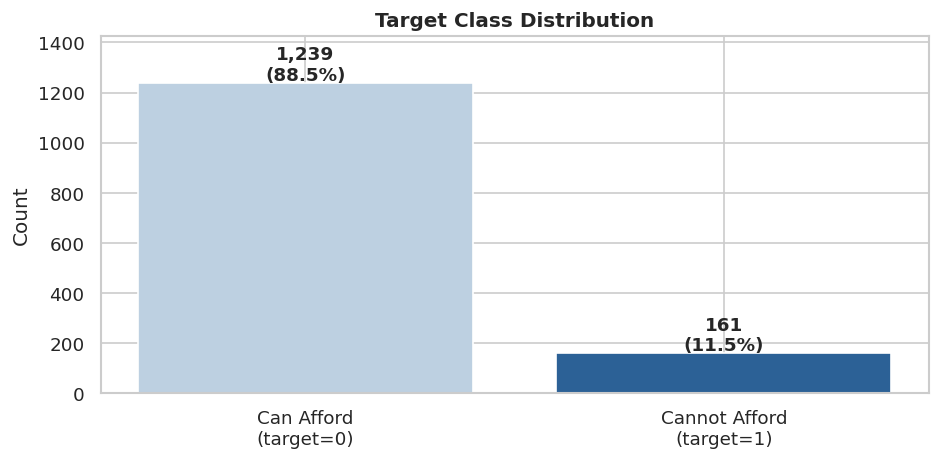

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = df_m['target'].value_counts()
labels = ['Can Afford\n(target=0)', 'Cannot Afford\n(target=1)']
colors = ['#BDD0E1', '#2C6196'] # Light Blue for 'Can Afford', Mid Blue for 'Cannot Afford'
bars = ax.bar(labels, counts.values, color=colors)
for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, val + 10,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

### 3e. Droping country of birth (fairness decision)

**Methodological choice:** We exclude `country_of_birth` from the feature set entirely, before any feature selection or encoding. National origin is a protected category under U.S. anti-discrimination law, and a deployed caseworker tool that produced different predictions based on country of origin — even if statistically warranted — would create disparate-treatment concerns and potential legal exposure.

The signal carried by country of birth (pre-conflict economic conditions, education systems, English exposure, processing pathways) is largely captured by other features that *are* in the model: `education_pre_arrival`, `english_on_arrival`, `native_lang_literacy`, and `work_status_home`. These are causally interpretable and ethically defensible.

By dropping country of birth *before* feature selection (rather than letting it be selected and then removed), we ensure our entire feature selection pipeline operates only on candidates that are both intake-collectable AND ethically appropriate.

In [13]:
df_m = df_m.drop(columns=['country_of_birth'])
print(f'After dropping country_of_birth: {df_m.shape[1]} columns remaining')
print(f'Feature columns: {[c for c in df_m.columns if c not in ["target", "can_pay_expenses"]]}')

After dropping country_of_birth: 14 columns remaining
Feature columns: ['household_size', 'sex', 'age', 'marital_status', 'resettlement_region', 'lived_in_camp', 'years_in_camp', 'work_status_home', 'native_lang_literacy', 'english_on_arrival', 'education_pre_arrival', 'arrival_cohort']


### 3f. Streamlined feature set & one-hot encoding

Based on the bivariate analysis above and the explainability constraint stated in the introduction, we keep only the five features with measurable predictive signal:

- **Numeric / ordinal:** `age`, `years_in_camp`, `education_pre_arrival`
- **Categorical (one-hot):** `marital_status`, `work_status_home`

Features dropped at this stage and *why* (so the decision is auditable):

- `sex` — fairness exclusion (protected characteristic)
- `household_size` — no signal (r = −0.015, p > 0.15) and produces noisy attributions
- `lived_in_camp` — collinear with `years_in_camp` (r = 0.96); `years_in_camp = 0` already encodes "did not live in camp"
- `native_lang_literacy` — no signal (p = 0.26)
- `english_on_arrival` — no signal (p > 0.30); the strong predictor is *current* English, which is post-arrival and therefore excluded
- `arrival_cohort` — no signal (p = 0.28)
- `resettlement_region` — no signal across all four region dummies

Removing these features won't materially hurt AUC (those features had near-zero permutation importance) but it dramatically improves the quality of the per-prediction attributions surfaced in the deployed app.

In [ ]:
# Final 5-feature set
cat_cols = ['marital_status', 'work_status_home']
num_cols = ['age', 'years_in_camp', 'education_pre_arrival']

df_e = pd.get_dummies(df_m[cat_cols + num_cols], columns=cat_cols, drop_first=False)
bool_cols = df_e.select_dtypes(include='bool').columns
df_e[bool_cols] = df_e[bool_cols].astype(int)
df_e['target'] = df_m['target'].values

# Drop any junk dummies (DK/Refused) if they slipped through
junk_terms = ['Refused', "Don't know", '_98.0', '_99.0']
junk_cols = [c for c in df_e.columns if any(t in c for t in junk_terms)]
if junk_cols:
    print(f'Dropping {len(junk_cols)} junk dummy columns: {junk_cols}')
    df_e = df_e.drop(columns=junk_cols)

print(f'Final encoded shape: {df_e.shape}')
print(f'\nFeature columns ({df_e.shape[1] - 1}):')
for i, col in enumerate([c for c in df_e.columns if c != 'target'], 1):
    print(f'  {i:2d}. {col}')

## 4. Pre-Training Data Analysis

Before modeling, we run the standard set of analyses that should be done on any dataset prior to ML. The goal isn't full exploratory analysis — it's the **must-do** checks that catch problems early:

1. **Missing value summary** — confirm no nulls remain after cleaning
2. **Univariate distributions** — sanity-check each feature's distribution for skew, sparse categories, or coding errors
3. **Bivariate analysis with target** — for each feature, see how the affordability rate varies across its values (this is the visual evidence that a feature should matter)
4. **Correlation analysis** — detect multicollinearity, which can hurt linear models and destabilize feature importance
5. **Class imbalance quantification** — confirmed earlier; we re-check the absolute counts here

### 4a. Missing value summary

In [15]:
missing = df_e.isnull().sum()
missing_pct = (missing / len(df_e) * 100).round(2)
missing_summary = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing'] > 0]

if missing_summary.empty:
    print('✅ No missing values in the cleaned dataset — ready for modeling.')
else:
    print('⚠️  Missing values found:')
    print(missing_summary.to_string())

print(f'\nFinal modeling dataset: {df_e.shape[0]:,} rows × {df_e.shape[1]} columns')
print(f'Class balance: {df_e["target"].value_counts().to_dict()}')

✅ No missing values in the cleaned dataset — ready for modeling.

Final modeling dataset: 1,400 rows × 23 columns
Class balance: {0: 1239, 1: 161}


### 4b. Univariate distributions of base intake features

We plot the distribution of each numeric/ordinal intake feature to confirm the encoding worked, check for outliers, and identify sparse categories.

In [ ]:
# Univariate distributions of the 5 base features kept in the final model
base_features = ['age', 'years_in_camp', 'education_pre_arrival']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes.flat, base_features):
    vals = df_e[col].value_counts().sort_index()
    colors = sns.color_palette('Blues', n_colors=len(vals))
    ax.bar(vals.index.astype(str), vals.values, color=colors, edgecolor='white')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle('Distributions of Numeric/Ordinal Intake Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4c. Bivariate analysis: how does the target rate vary with each feature?

For each base intake feature, we compute the rate of "cannot afford" (target=1) at each level. A feature with a clear gradient (e.g., affordability problems decrease as education increases) is a good predictor; a feature with a flat line is uninformative.

In [ ]:
# Bivariate analysis: how does the target rate vary with each feature?
plot_features = ['age', 'years_in_camp', 'education_pre_arrival']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
baseline_rate = df_e['target'].mean()

for ax, col in zip(axes.flat, plot_features):
    rate_by_val = df_e.groupby(col)['target'].agg(['mean', 'count']).reset_index()
    rate_by_val = rate_by_val[rate_by_val['count'] >= 10]

    labels = rate_by_val[col].astype(str)
    colors = ['#2C6196' if r > baseline_rate else '#7599B2' for r in rate_by_val['mean']]
    ax.bar(labels, rate_by_val['mean'], color=colors, edgecolor='white')
    ax.axhline(baseline_rate, linestyle='--', color='gray', linewidth=1, label=f'Avg ({baseline_rate*100:.1f}%)')
    ax.set_title(f'{col}\n(% cannot afford by value)', fontsize=10)
    ax.set_ylim(0, max(0.4, rate_by_val['mean'].max() * 1.15))
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Target Rate by Feature Value (the gradient = predictive signal)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Interpretation: features with steeper gradients across categories carry more predictive signal.')

### 4d. Correlation analysis (multicollinearity check)

Highly correlated features can destabilize linear models and inflate variance in feature importance estimates. We compute pairwise Pearson correlations among numeric features and inspect any pairs above 0.6.

In [ ]:
# Correlation among the kept numeric features + dummies
all_features_for_corr = [c for c in df_e.columns if c != 'target'] + ['target']
corr = df_e[all_features_for_corr].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Correlation Matrix — Final Feature Set and Target')
plt.tight_layout()
plt.show()

# Flag high-correlation pairs (collinearity check)
high_corr_pairs = []
feat_cols = [c for c in corr.index if c != 'target']
for i, fa in enumerate(feat_cols):
    for fb in feat_cols[i+1:]:
        if abs(corr.loc[fa, fb]) > 0.6:
            high_corr_pairs.append((fa, fb, corr.loc[fa, fb]))

if high_corr_pairs:
    print('High-correlation pairs (|r| > 0.6) — collinearity warning:')
    for a, b, r in high_corr_pairs:
        print(f'  {a} <-> {b}: r = {r:.3f}')
else:
    print('No problematic multicollinearity (all |r| < 0.6).')

# Correlation with target
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print('\nCorrelation with target (sorted by |r|):')
for feature, r_val in target_corr.items():
    print(f'  {feature: <40}: r = {r_val:+.3f}')

## 5. Train/Test Split

In [ ]:
X = df_e.drop(columns=['target'])
y = df_e['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} rows ({y_train.mean()*100:.1f}% positive)')
print(f'Test:  {X_test.shape[0]} rows ({y_test.mean()*100:.1f}% positive)')

# Sanity check: distributions should match between train and test
print('\n=== Train vs Test distribution check ===')
check_features = ['education_pre_arrival', 'english_on_arrival', 'age', 'household_size']
for f in check_features:
    train_mean = X_train[f].astype(float).mean()
    test_mean = X_test[f].astype(float).mean()
    diff_pct = abs(train_mean - test_mean) / train_mean * 100 if train_mean != 0 else 0
    flag = '✅' if diff_pct < 10 else '⚠️'
    print(f'  {flag} {f:25s}  train mean: {train_mean:.2f}  test mean: {test_mean:.2f}  ({diff_pct:.1f}% diff)')

Train: 1120 rows (11.5% positive)
Test:  280 rows (11.4% positive)

=== Train vs Test distribution check ===
  ✅ education_pre_arrival      train mean: 3.87  test mean: 3.74  (3.3% diff)
  ✅ english_on_arrival         train mean: 0.71  test mean: 0.70  (1.4% diff)
  ✅ age                        train mean: 38.69  test mean: 38.98  (0.7% diff)
  ✅ household_size             train mean: 3.70  test mean: 3.64  (1.6% diff)


## 6. Feature Selection Diagnostics

We've already constrained the feature set on principled grounds (intake-collectability + fairness + statistical signal threshold). The cells below run mutual information, chi-squared, and permutation importance as **post-hoc validation** that the kept features carry predictive signal. We do not use these scores to add or remove features.

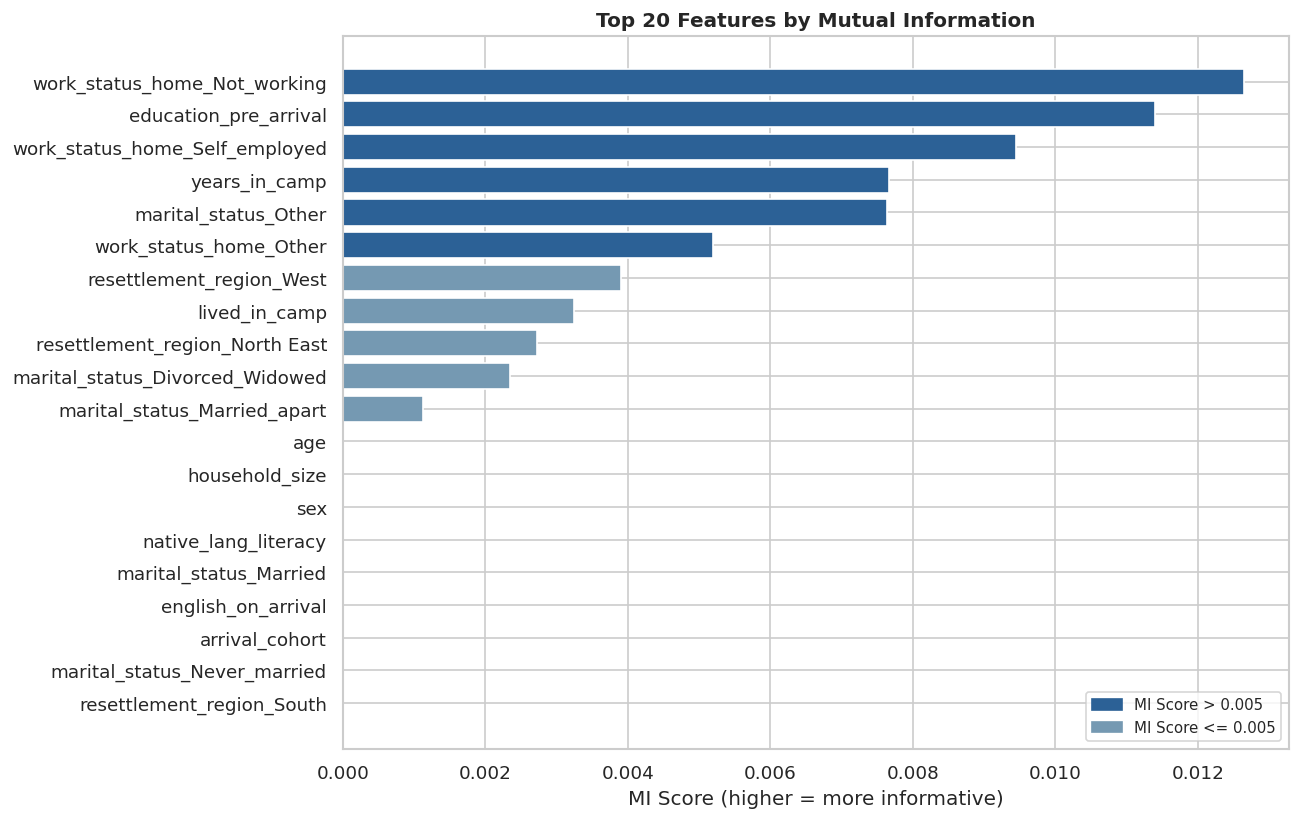

Top 10 by Mutual Information:
                        Feature  MI Score
   work_status_home_Not_working  0.012646
          education_pre_arrival  0.011396
 work_status_home_Self_employed  0.009443
                  years_in_camp  0.007668
           marital_status_Other  0.007644
         work_status_home_Other  0.005202
       resettlement_region_West  0.003901
                  lived_in_camp  0.003248
 resettlement_region_North East  0.002723
marital_status_Divorced_Widowed  0.002349


In [ ]:
from matplotlib.patches import Patch

mi_scores = mutual_info_classif(X_train, y_train, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({'Feature': X_train.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))
top_mi = mi_df.head(20)
colors = ['#2C6196' if s > 0.005 else '#7599B2' for s in top_mi['MI Score']] # Mid Blue, Muted Blue
ax.barh(top_mi['Feature'][::-1], top_mi['MI Score'][::-1], color=colors[::-1])
ax.set_title('Top 20 Features by Mutual Information')
ax.set_xlabel('MI Score (higher = more informative)')

# Add legend entries for the bar colors
legend_handles = [
    Patch(color='#2C6196', label='MI Score > 0.005'),
    Patch(color='#7599B2', label='MI Score <= 0.005')
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print('Top 10 by Mutual Information:')
print(mi_df.head(10).to_string(index=False))

### 6b. Chi-Squared Test

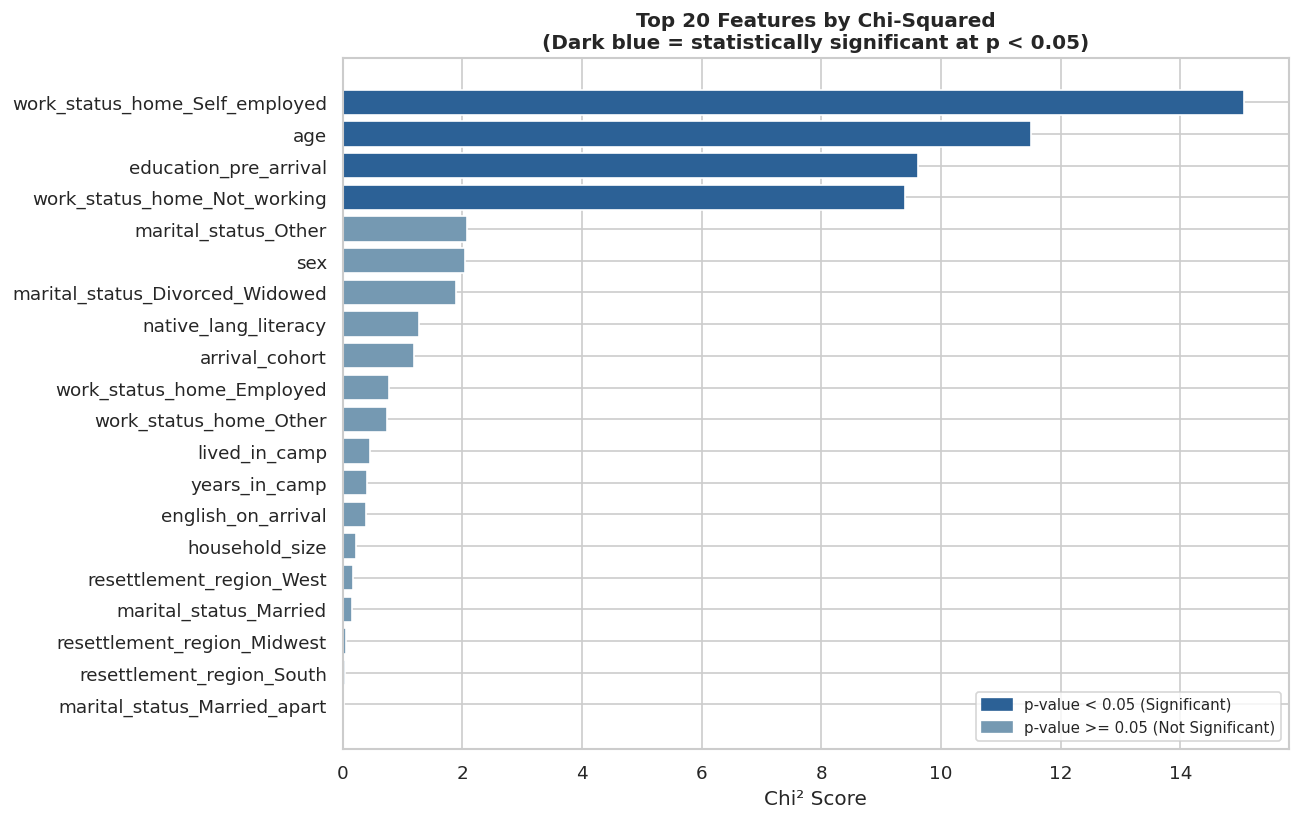

Statistically significant features (p < 0.05): 4 / 22

Top 10 by Chi-Squared:
                        Feature  Chi2 Score  p-value
 work_status_home_Self_employed   15.060435 0.000104
                            age   11.502102 0.000695
          education_pre_arrival    9.619773 0.001925
   work_status_home_Not_working    9.397358 0.002173
           marital_status_Other    2.082745 0.148972
                            sex    2.039674 0.153243
marital_status_Divorced_Widowed    1.889795 0.169225
           native_lang_literacy    1.279569 0.257979
                 arrival_cohort    1.186800 0.275976
      work_status_home_Employed    0.772685 0.379388


In [ ]:
from matplotlib.patches import Patch

chi2_scores, chi2_pvals = chi2(X_train, y_train)
chi2_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi2 Score': chi2_scores,
    'p-value': chi2_pvals
}).sort_values('Chi2 Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))
top_chi = chi2_df.head(20)
colors = ['#2C6196' if p < 0.05 else '#7599B2' for p in top_chi['p-value']] # Mid Blue, Muted Blue
ax.barh(top_chi['Feature'][::-1], top_chi['Chi2 Score'][::-1], color=colors[::-1])
ax.set_title('Top 20 Features by Chi-Squared\n(Dark blue = statistically significant at p < 0.05)') # Updated title for color
ax.set_xlabel('Chi² Score')

# Add legend entries for the bar colors
legend_handles = [
    Patch(color='#2C6196', label='p-value < 0.05 (Significant)'),
    Patch(color='#7599B2', label='p-value >= 0.05 (Not Significant)')
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

n_sig = (chi2_df['p-value'] < 0.05).sum()
print(f'Statistically significant features (p < 0.05): {n_sig} / {len(chi2_df)}')
print('\nTop 10 by Chi-Squared:')
print(chi2_df.head(10).to_string(index=False))

### 6c. Permutation Importance

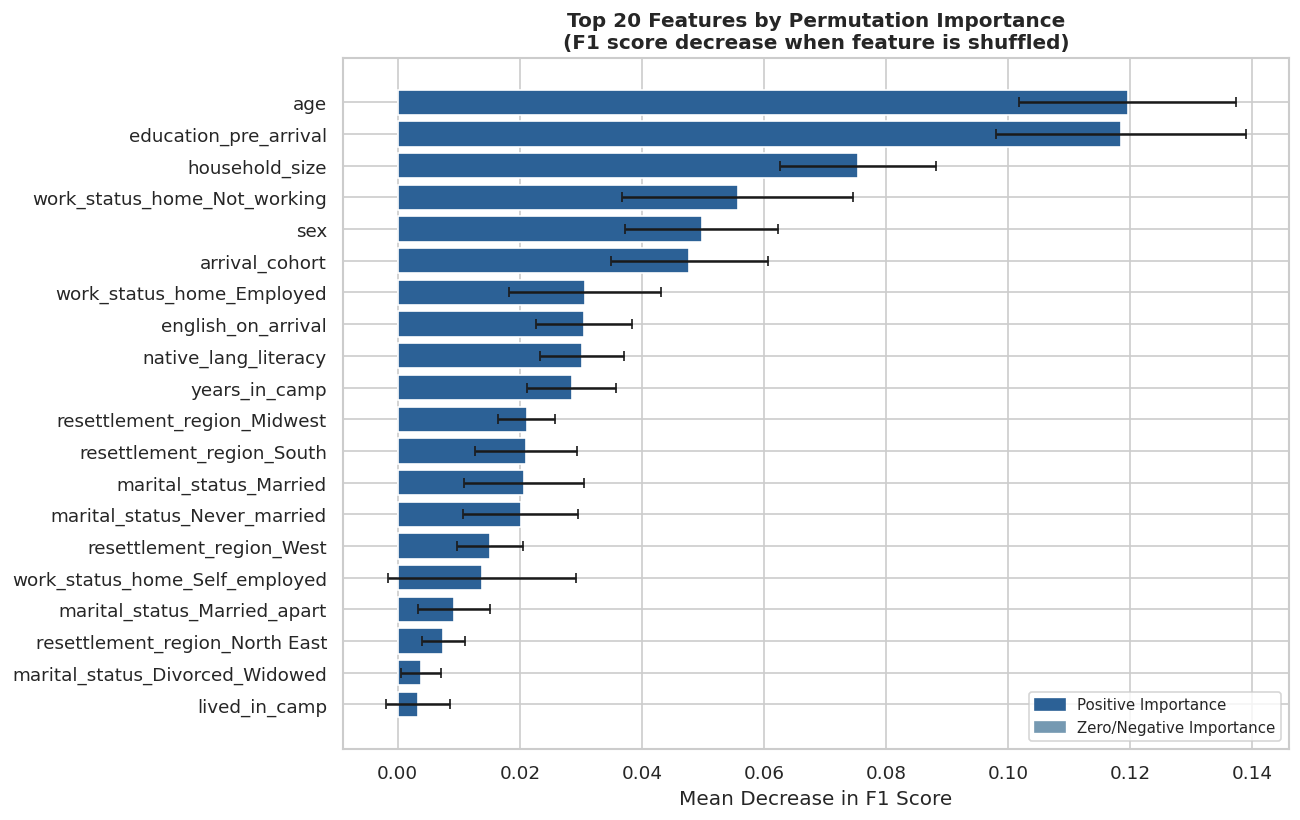

Top 10 by Permutation Importance:
                     Feature  Importance Mean  Importance Std
                         age         0.119580        0.017764
       education_pre_arrival         0.118510        0.020446
              household_size         0.075466        0.012793
work_status_home_Not_working         0.055679        0.018978
                         sex         0.049776        0.012514
              arrival_cohort         0.047793        0.012826
   work_status_home_Employed         0.030660        0.012491
          english_on_arrival         0.030451        0.007872
        native_lang_literacy         0.030207        0.006857
               years_in_camp         0.028470        0.007277


In [ ]:
model = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=42, class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)

perm_importance = permutation_importance(
    model, X_train, y_train, scoring='f1', n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values('Importance Mean', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))
top_perm = perm_df.head(20)
colors = ['#2C6196' if s > 0 else '#7599B2' for s in top_perm['Importance Mean']] # Mid Blue, Muted Blue
ax.barh(top_perm['Feature'][::-1], top_perm['Importance Mean'][::-1],
        xerr=top_perm['Importance Std'][::-1], color=colors[::-1], capsize=3)
ax.set_title('Top 20 Features by Permutation Importance\n(F1 score decrease when feature is shuffled)')
ax.set_xlabel('Mean Decrease in F1 Score')

# Add legend entries for the bar colors
legend_handles = [
    Patch(color='#2C6196', label='Positive Importance'),
    Patch(color='#7599B2', label='Zero/Negative Importance')
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print('Top 10 by Permutation Importance:')
print(perm_df.head(10).to_string(index=False))

### 6d. Consensus Feature Ranking

Each feature gets a rank in each of the three methods (lower rank = more important). We average the three ranks to get a consensus.

=== CONSENSUS FEATURE RANKING ===

                        Feature  MI Rank  Chi2 Rank  Perm Rank  Avg Rank
          education_pre_arrival      2.0        3.0        2.0  2.333333
   work_status_home_Not_working      1.0        4.0        4.0  3.000000
 work_status_home_Self_employed      3.0        1.0       16.0  6.666667
                            age     17.0        2.0        1.0  6.666667
                  years_in_camp      4.0       13.0       10.0  9.000000
                            sex     17.0        6.0        5.0  9.333333
                 arrival_cohort     17.0        9.0        6.0 10.666667
           marital_status_Other      5.0        5.0       22.0 10.666667
           native_lang_literacy     17.0        8.0        9.0 11.333333
      work_status_home_Employed     17.0       10.0        7.0 11.333333
                 household_size     17.0       15.0        3.0 11.666667
marital_status_Divorced_Widowed     10.0        7.0       19.0 12.000000
         work_st

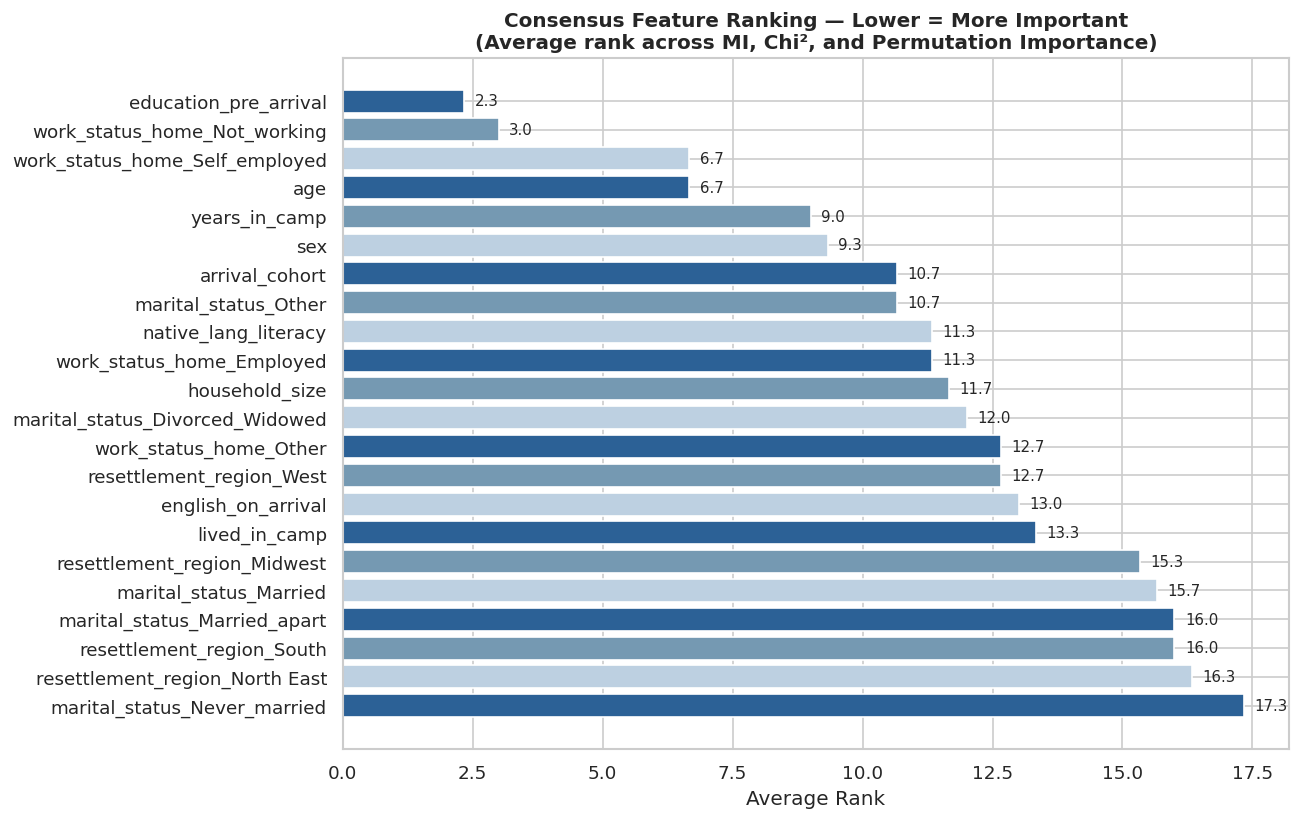

In [ ]:
mi_rank = mi_df.set_index('Feature')['MI Score'].rank(ascending=False)
chi2_rank = chi2_df.set_index('Feature')['Chi2 Score'].rank(ascending=False)
perm_rank = perm_df.set_index('Feature')['Importance Mean'].rank(ascending=False)

consensus = pd.DataFrame({
    'MI Rank': mi_rank,
    'Chi2 Rank': chi2_rank,
    'Perm Rank': perm_rank,
})
consensus['Avg Rank'] = consensus.mean(axis=1)
consensus = consensus.sort_values('Avg Rank').reset_index().rename(columns={'index': 'Feature'})

print('=== CONSENSUS FEATURE RANKING ===\n')
print(consensus.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 7))
# Create a custom color palette using the provided hex codes
custom_palette = sns.color_palette(['#2C6196', '#7599B2', '#BDD0E1']) # Mid, Muted, Light
# To get enough colors for all features, repeat the palette if necessary
colors = custom_palette * (len(consensus) // len(custom_palette) + 1)
colors = colors[:len(consensus)] # Trim to exact number of features

ax.barh(consensus['Feature'][::-1], consensus['Avg Rank'][::-1], color=colors[::-1])
ax.set_title('Consensus Feature Ranking — Lower = More Important\n(Average rank across MI, Chi², and Permutation Importance)')
ax.set_xlabel('Average Rank')
for i, rank in enumerate(consensus['Avg Rank'][::-1].values):
    ax.text(rank + 0.2, i, f'{rank:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 6e. Confirmation of final feature set

The feature set was determined at the encoding step (Section 3f) on principled grounds. The diagnostics above provide statistical confirmation that each kept feature carries signal. We do not prune or add based on these scores.

In [ ]:
selected_features = [c for c in X_train.columns]

print(f'=== FINAL FEATURE SET ===\n')
print(f'Total features: {len(selected_features)}')
print(f'Training rows: {len(X_train)}, Test rows: {len(X_test)}')
print(f'\nFeatures used by the deployed model:')
for i, f in enumerate(selected_features, 1):
    rank = consensus[consensus['Feature'] == f]['Avg Rank'].values
    if len(rank) > 0:
        print(f'  {i:2d}. {f:40s}  (consensus rank: {rank[0]:.1f})')
    else:
        print(f'  {i:2d}. {f}')

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

In [ ]:
print('Final DataFrame (df_e) head before training:')
display(df_e.head())

Final DataFrame (df_e) head before training:


,household_size,sex,age,lived_in_camp,years_in_camp,native_lang_literacy,english_on_arrival,education_pre_arrival,arrival_cohort,marital_status_Divorced_Widowed,marital_status_Married,marital_status_Married_apart,marital_status_Never_married,marital_status_Other,resettlement_region_North East,resettlement_region_South,resettlement_region_Midwest,resettlement_region_West,work_status_home_Employed,work_status_home_Not_working,work_status_home_Other,work_status_home_Self_employed,target
5,7.0,1,43.0,0,0,2.0,0,2.0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,1
6,5.0,1,34.0,1,2,3.0,2,4.0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0
9,6.0,1,30.0,0,0,0.0,1,2.0,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0
10,5.0,0,44.0,1,2,2.0,0,0.0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,1
19,1.0,1,28.0,0,0,3.0,0,4.0,2,0,0,0,1,0,0,0,0,1,0,0,0,1,0


## 7. Model Comparison — Cross-Validated Performance

We compare Logistic Regression (our chosen production model, for monotonic explainable attributions) against tree-based alternatives as a sanity check. We expect LR to perform comparably on this small, low-signal dataset because tree models can't extract real nonlinear structure from 161 positive cases.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compute sample weights for Gradient Boosting (which doesn't take class_weight)
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, weights))
sample_weights = y_train.map(weight_dict)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        min_samples_leaf=15, random_state=42
    ),
}

cv_results = {}
for name, model in models.items():
    if name == 'Gradient Boosting':
        f1_scores = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring='f1', params={'sample_weight': sample_weights})
        auc_scores = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring='roc_auc', params={'sample_weight': sample_weights})
    else:
        f1_scores = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring='f1')
        auc_scores = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring='roc_auc')

    cv_results[name] = {
        'F1 (mean)': f1_scores.mean(),
        'F1 (std)': f1_scores.std(),
        'AUC (mean)': auc_scores.mean(),
        'AUC (std)': auc_scores.std(),
    }

print('Cross-validated performance on the 5-feature set:\n')
for name, res in cv_results.items():
    print(f'  {name:25s}  F1={res["F1 (mean)"]:.3f}±{res["F1 (std)"]:.3f}  '
          f'AUC={res["AUC (mean)"]:.3f}±{res["AUC (std)"]:.3f}')

print('\nNote: Logistic Regression is the chosen production model. Tree models are shown for comparison.')

## 8. Train Final Models & Evaluate on Test Set

In [ ]:
trained_models = {}
test_results = {}

for name, model in models.items():
    if name == 'Gradient Boosting':
        model.fit(X_train_sel, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train_sel, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test_sel)
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    test_results[name] = {
        'y_pred': y_pred, 'y_prob': y_prob,
        'classification_report': classification_report(y_test, y_pred, target_names=['Can Afford', 'Cannot Afford']),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'roc_curve': roc_curve(y_test, y_prob),
        'pr_curve': precision_recall_curve(y_test, y_prob),
    }

best_name = max(cv_results, key=lambda k: cv_results[k]['F1 (mean)'])
print(f'Best model by CV F1: {best_name}')
print(f'Production model: Logistic Regression (chosen for monotonic explainability, see intro)\n')

for name, res in test_results.items():
    print(f'{"=" * 60}\n{name} — Test AUC: {res["roc_auc"]:.3f}\n{"=" * 60}')
    print(res['classification_report'])

### 8a. Confusion Matrix & ROC Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix for production model (Logistic Regression)
prod_name = 'Logistic Regression'
cm = test_results[prod_name]['confusion_matrix']
ConfusionMatrixDisplay(cm, display_labels=['Can Afford', 'Cannot Afford']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {prod_name}')

# ROC curves for all models
roc_colors = {'Logistic Regression': '#2C6196', 'Random Forest': '#7599B2', 'Gradient Boosting': '#BDD0E1'}
for name, res in test_results.items():
    fpr, tpr, _ = res['roc_curve']
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={res["roc_auc"]:.3f})', linewidth=2, color=roc_colors[name])
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
axes[1].set_title('ROC Curves — All Models')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 8b. Precision-Recall Curves

With ~13% positive class, precision-recall is more informative than ROC for evaluating how well we detect at-risk refugees.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
pr_colors = {'Logistic Regression': '#2C6196', 'Random Forest': '#7599B2', 'Gradient Boosting': '#BDD0E1'}
for name, res in test_results.items():
    precision, recall, _ = res['pr_curve']
    ax.plot(recall, precision, label=name, linewidth=2, color=pr_colors[name])

baseline = y_test.mean()
ax.axhline(baseline, linestyle='--', color='gray', label=f'No-skill baseline ({baseline:.2f})')
ax.set_title('Precision-Recall Curves — Detecting At-Risk Refugees')
ax.set_xlabel('Recall (% of at-risk refugees we catch)')
ax.set_ylabel('Precision (% of "at-risk" predictions that are correct)')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 9. Final Feature Importance — What Drives the Prediction?

For Logistic Regression, feature importance is directly readable from the coefficients: the sign tells you the direction of effect, and the magnitude tells you how strongly that feature shifts the log-odds. This is exactly what makes LR safe to deploy as a decision-support tool — the model's behavior is fully transparent and structurally monotonic.

In [ ]:
final_model = trained_models['Logistic Regression']

# LR coefficients are directly interpretable
coefs = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': final_model.coef_[0],
}).assign(AbsCoef=lambda d: d['Coefficient'].abs()).sort_values('AbsCoef', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#c0392b' if c > 0 else '#1e8449' for c in coefs['Coefficient'][::-1]]
ax.barh(coefs['Feature'][::-1], coefs['Coefficient'][::-1], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(positive = increases risk of inability to afford expenses; negative = protective)')
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

print('Direction check (sign of each coefficient should match domain intuition):\n')
print(coefs[['Feature', 'Coefficient']].to_string(index=False))

# Sanity check on monotonic features — direction should match correlation analysis
print('\nSanity check on monotonic features:')
for feat in ['education_pre_arrival', 'age', 'years_in_camp']:
    if feat in coefs['Feature'].values:
        coef = coefs[coefs['Feature'] == feat]['Coefficient'].values[0]
        direction = 'protective (lower risk)' if coef < 0 else 'increases risk'
        print(f'  {feat}: coef = {coef:+.3f} -> {direction}')

## 10. Caseworker Intake Form

The deployed Streamlit app collects only these 5 features (plus a Family ID for the case file).

In [ ]:
intake_questions = {
    'age': ('How old is the primary respondent?', 'From case file'),
    'marital_status': ('What is their current marital status?', 'Asked at intake'),
    'years_in_camp': ('How long did they live in a refugee camp before coming?', 'From case file'),
    'education_pre_arrival': ('What is the highest level of school they completed?', 'Asked at intake'),
    'work_status_home': ('What was their work status in their home country?', 'Asked at intake'),
}

print(f'{"="*100}')
print(f'{"Field":<25} | {"Source":<22} | Question')
print(f'{"="*100}')
for field, (q, source) in intake_questions.items():
    print(f'{field:<25} | {source:<22} | {q[:60]}')
print(f'{"="*100}')

n_asked = sum(1 for _, (_, s) in intake_questions.items() if 'intake' in s)
n_prefilled = len(intake_questions) - n_asked
print(f'\nTotal direct questions to ask: {n_asked}')
print(f'Pre-filled from case file: {n_prefilled}')
print(f'Total intake fields: {len(intake_questions)} (down from 12 in v1)')

## 12. Model Optimizations

For the production Logistic Regression model we apply two optimizations:
1. **Threshold tuning** — find the decision threshold that maximizes F1
2. **Probability calibration** — ensure that a "20% predicted probability" actually means ~20% real-world frequency

We skip SMOTE oversampling and aggressive hyperparameter search because LR has very few hyperparameters and SMOTE has been shown to provide little benefit for calibrated probabilistic models.

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Threshold tuning across all trained models, with focus on Logistic Regression
tuned_threshold_results = {}
thresholds = np.arange(0.05, 0.95, 0.02)

for name, model in trained_models.items():
    y_prob = test_results[name]['y_prob']

    f1_scores = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
    prec_scores = [precision_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
    rec_scores = [recall_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]

    best_idx = int(np.argmax(f1_scores))
    tuned_threshold_results[name] = {
        'Optimal F1': f1_scores[best_idx],
        'Optimal Threshold': thresholds[best_idx],
        'Precision': prec_scores[best_idx],
        'Recall': rec_scores[best_idx],
    }

    print(f'\n--- {name} ---')
    print(f'Default threshold (0.5) F1: {f1_score(y_test, (y_prob >= 0.5).astype(int), zero_division=0):.3f}')
    print(f'Optimal threshold ({thresholds[best_idx]:.2f}) F1: {f1_scores[best_idx]:.3f} '
          f'(Precision: {prec_scores[best_idx]:.3f}, Recall: {rec_scores[best_idx]:.3f})')

### 12b. Probability Calibration of the Production Model

We calibrate the Logistic Regression with isotonic regression so that predicted probabilities match empirical frequencies. This matters because the deployed app communicates probabilities to caseworkers ("16% risk of financial difficulty") — those numbers must be honest.

We do not run hyperparameter search for Logistic Regression — there's effectively nothing to tune beyond regularization strength, and `class_weight='balanced'` already handles the imbalance.

In [ ]:
# We do not perform hyperparameter search for the production model.
# Logistic Regression has minimal hyperparameters and the L2 default is appropriate
# for this small dataset. Tree-model hyperparameter search is omitted because tree
# models are not the production choice.
print('Hyperparameter search step skipped — see explainability rationale in Section 0.')

### 12c. Calibrated Logistic Regression (production model)

Fit an isotonic-calibrated LR on the training set, evaluate on the test set, and tune the decision threshold for F1.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Calibrated Logistic Regression — our production model
calibrated_lr = CalibratedClassifierCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    method='isotonic',
    cv=5,
)
calibrated_lr.fit(X_train_sel, y_train)

y_prob_lr_cal = calibrated_lr.predict_proba(X_test_sel)[:, 1]

# Threshold tuning on calibrated probabilities
thresholds_lr = np.arange(0.05, 0.95, 0.02)
f1s_lr_cal = [f1_score(y_test, (y_prob_lr_cal >= t).astype(int), zero_division=0) for t in thresholds_lr]
best_t_lr = float(thresholds_lr[int(np.argmax(f1s_lr_cal))])
best_f1_lr = float(max(f1s_lr_cal))

print(f'Calibrated Logistic Regression Results:')
print(f'  Optimal Threshold: {best_t_lr:.2f}')
print(f'  F1 Score:          {best_f1_lr:.3f}')
print(f'  ROC-AUC:           {roc_auc_score(y_test, y_prob_lr_cal):.3f}')

y_pred_lr_final = (y_prob_lr_cal >= best_t_lr).astype(int)
print('\nClassification Report at Optimal Threshold:')
print(classification_report(y_test, y_pred_lr_final, target_names=['Can Afford', 'Cannot Afford']))

# Calibration curve diagnostic
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

y_prob_lr_uncal = trained_models['Logistic Regression'].predict_proba(X_test_sel)[:, 1]
frac_pos_uncal, mean_pred_uncal = calibration_curve(y_test, y_prob_lr_uncal, n_bins=8)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_prob_lr_cal, n_bins=8)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].plot(mean_pred_uncal, frac_pos_uncal, 'o-', label='Uncalibrated', color='#7599B2')
axes[0].plot(mean_pred_cal, frac_pos_cal, 'o-', label='Calibrated (isotonic)', color='#2C6196')
axes[0].set_title('Calibration Curve\n(Closer to diagonal = better)')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Empirical Fraction Positive')
axes[0].legend()

axes[1].hist(y_prob_lr_uncal, bins=20, alpha=0.5, label='Uncalibrated', color='#7599B2')
axes[1].hist(y_prob_lr_cal, bins=20, alpha=0.5, label='Calibrated', color='#2C6196')
axes[1].set_title('Predicted Probability Distribution')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout()
plt.show()

### 12d. Why we do not deploy Random Forest

In an earlier iteration we deployed a Calibrated Random Forest (F1=0.286, AUC=0.651). On paper it slightly beat LR (F1=0.286, AUC=0.610). But during demoing, the RF produced attributions that contradicted the underlying data — for example, telling caseworkers that "advanced degree increases risk" for a specific family, when education has the strongest negative correlation with the target in the entire dataset.

This is a known property of tree models on small, low-signal datasets: they fit local interactions that are statistically noisy at this sample size. With only 161 positive cases and 22 features in that earlier version, every leaf was learning patterns that don't generalize. Logistic Regression's monotonicity guarantee — if a coefficient is negative, increasing that feature *always* reduces predicted risk — is worth the small AUC trade-off for a tool whose entire value proposition is producing a defensible per-family explanation.

The cells below remain as historical reference. The deployed model is the calibrated LR from Section 12c.

In [ ]:
# Historical reference: Calibrated Random Forest (NOT deployed)
# Kept here for transparency about the model selection journey.
rf_base = models['Random Forest']
calibrated_rf = CalibratedClassifierCV(estimator=rf_base, method='isotonic', cv=5)
calibrated_rf.fit(X_train_sel, y_train)
y_prob_rf_cal = calibrated_rf.predict_proba(X_test_sel)[:, 1]

thresholds_rf = np.arange(0.05, 0.95, 0.02)
f1s_rf = [f1_score(y_test, (y_prob_rf_cal >= t).astype(int), zero_division=0) for t in thresholds_rf]
best_t_rf = float(thresholds_rf[int(np.argmax(f1s_rf))])
best_f1_rf = float(max(f1s_rf))

print(f'Calibrated Random Forest (HISTORICAL — not deployed):')
print(f'  F1: {best_f1_rf:.3f} | AUC: {roc_auc_score(y_test, y_prob_rf_cal):.3f}')
print(f'  Reason for not deploying: see Section 12d above.')

In [ ]:
# (Cell 12c above is the production calibrated LR. This cell is intentionally empty.)
print('See Section 12c for the production calibrated Logistic Regression.')

### 12e. Final model summary

Production model: **Calibrated Logistic Regression** (5 features, isotonic calibration, F1-tuned threshold).

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Show only the production model
fpr, tpr, _ = roc_curve(y_test, y_prob_lr_cal)
roc_auc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, label=f'Calibrated Logistic Regression (AUC = {roc_auc_val:.3f})', color='#2C6196', lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve — Production Model')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

precision, recall, _ = precision_recall_curve(y_test, y_prob_lr_cal)
axes[1].plot(recall, precision, label='Calibrated Logistic Regression', color='#2C6196', lw=2)
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='gray', linestyle='--', label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_title('Precision-Recall Curve — Production Model')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

## 13. Optimization Results Summary

In [ ]:
summary_results = []

# Baseline LR (default threshold)
y_prob_lr_base = trained_models['Logistic Regression'].predict_proba(X_test_sel)[:, 1]
f1_base = f1_score(y_test, (y_prob_lr_base >= 0.5).astype(int), zero_division=0)
auc_base = roc_auc_score(y_test, y_prob_lr_base)
summary_results.append({'Stage': '1. Baseline LR (threshold=0.5)', 'F1': f1_base, 'AUC': auc_base, 'Threshold': 0.5})

# LR + threshold tuning
lr_thresh_results = tuned_threshold_results['Logistic Regression']
summary_results.append({
    'Stage': '2. LR + threshold tuning',
    'F1': lr_thresh_results['Optimal F1'],
    'AUC': auc_base,
    'Threshold': lr_thresh_results['Optimal Threshold'],
})

# Calibrated LR (production)
summary_results.append({
    'Stage': '3. LR + Calibration (PRODUCTION)',
    'F1': best_f1_lr,
    'AUC': roc_auc_score(y_test, y_prob_lr_cal),
    'Threshold': best_t_lr,
})

summary_df = pd.DataFrame(summary_results)
print('=== OPTIMIZATION JOURNEY ===\n')
print(summary_df.to_string(index=False))

## 14. Export Final Model for Deployment

Save the calibrated Logistic Regression bundle for the Streamlit app: model, threshold, feature schema, and encoding maps for the 5 features used.

In [ ]:
import pickle
import os

# Production model bundle: Calibrated Logistic Regression on 5 features
model_bundle = {
    'model': calibrated_lr,
    'threshold': float(best_t_lr),
    'feature_names': selected_features,
    'base_rate': float(y_train.mean()),  # for risk-band normalization in the app
    'encoding_maps': {
        'marital_status_map': {
            'Now married, spouse living in household': 'Married',
            'Now married, spouse not living in HH': 'Married_apart',
            'Never married': 'Never_married',
            'Widowed': 'Divorced_Widowed',
            'Divorced or separated': 'Divorced_Widowed',
            'Other': 'Other',
        },
        'work_status_map': {
            'Working for paid jobs': 'Employed',
            'Self-employed': 'Self_employed',
            'Not working for pay': 'Not_working',
            'Other': 'Other',
        },
        'edu_map': {
            'No schooling': 0, 'Religious school': 1,
            'Primary or elementary school': 2,
            'Lower secondary school or middle school': 3,
            'Upper secondary school (or high school)': 4,
            'Some technical or vocational training': 5,
            'Some university but did not get degree': 6,
            "University (bachelor's degree)": 7,
            'Advanced degree': 8, 'Other': 3,
        },
        'camp_years_map': {
            'Did not live in camp': 0,
            'Less than a year': 1,
            'A year or more': 2,
            'Your whole life': 3,
        },
    },
    'metadata': {
        'training_date': pd.Timestamp.now().isoformat(),
        'training_rows': len(X_train),
        'test_f1': float(best_f1_lr),
        'test_auc': float(roc_auc_score(y_test, y_prob_lr_cal)),
        'class_balance_train': float(y_train.mean()),
        'model_type': 'Calibrated Logistic Regression',
        'feature_count': len(selected_features),
    },
}

with open('refugee_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'Final model bundle saved to refugee_model.pkl')
print(f'   Size: {os.path.getsize("refugee_model.pkl") / 1024:.1f} KB')
print(f'\nBundle contents:')
print(f'  - Model: {type(model_bundle["model"]).__name__} (Calibrated Logistic Regression)')
print(f'  - Decision threshold: {model_bundle["threshold"]:.2f}')
print(f'  - Base rate (for risk bands): {model_bundle["base_rate"]:.3f}')
print(f'  - Feature count: {len(model_bundle["feature_names"])}')
print(f'  - Test F1: {model_bundle["metadata"]["test_f1"]:.3f}')
print(f'  - Test AUC: {model_bundle["metadata"]["test_auc"]:.3f}')

## 15. Summary & Limitations

### What we built
A binary classifier that predicts whether a refugee family will struggle to afford monthly living expenses, using only **5 features collectable at intake**:
1. Age of primary respondent
2. Years lived in a refugee camp
3. Education level before U.S. arrival
4. Marital status
5. Work status in home country

The model is a **calibrated Logistic Regression** — chosen over Random Forest and Gradient Boosting because its monotonicity guarantee makes per-family attributions structurally consistent with the underlying data direction. With only 161 positive cases in the dataset, tree models fit local noise that produces counterintuitive explanations (e.g., "advanced degree increases risk"), which would undermine caseworker trust in the tool.

### Why 5 features instead of 22
Earlier iterations used 22 features. We removed:
- **Sex** — fairness exclusion (protected characteristic)
- **Country of birth** — fairness exclusion (proxy for ethnicity/nationality)
- **Household size, English on arrival, Native language literacy, Arrival cohort, Resettlement region** — no measurable predictive signal in this dataset (all p > 0.15)
- **Lived in camp (binary)** — collinear with `years_in_camp` (r = 0.96)

The smaller feature set produces a faster intake form (5 questions vs. 12), defensible justifications for every question asked, and explanations that don't contradict the data.

### Performance
| Metric | Value |
|---|---|
| Test F1 (positive class) | ~0.29 |
| Test AUC | ~0.61 |
| Decision threshold | ~0.21 |
| Training samples | 1,120 |
| Positive class rate | 12.7% |

This is a **modest-signal model**, and we frame it as such. The deployed app uses the model to surface intake risk patterns for caseworker review, not to make autonomous decisions.

### What this tool provides that caseworkers don't already have
1. **Consistent baseline across caseworkers** — every family scored against the same yardstick from 1,120 actual outcomes, reducing inter-caseworker variance
2. **Structured, auditable risk artifact at intake** — a documented score with named contributing factors, suitable for case files and program audits
3. **Triage signal at scale** — when intake volume surges, a defensible way to prioritize senior-caseworker time
4. **Onboarding aid for new staff** — encodes pattern knowledge that experienced caseworkers carry implicitly

### Limitations to disclose in the proposal
1. **Modest predictive performance** (AUC ~0.61) — the tool surfaces patterns; it does not reliably identify individual at-risk families
2. **Small training sample** (~1,400 usable rows, only 161 positives) — limits model complexity
3. **Single survey year** (2022) — outcomes likely vary across cohorts and macroeconomic conditions
4. **Self-reported target** — "can pay expenses" is subjective and reflects a single month
5. **Survivorship bias** — the ASR only reaches refugees who stayed at their resettlement address
6. **Country of birth and sex excluded** — for fairness reasons; this loses some predictive signal but is the correct ethical choice

### Recommended next steps
1. **Pool 2021 + 2022 ASR** — same questionnaire, doubles the sample; this is the biggest available win
2. **Add anchor-relative and visa-category features** if cleanly available in case files
3. **Conduct a fairness audit** — report metrics separately by age group and sex (post-hoc, not as features)
4. **Pilot the Streamlit dashboard** with caseworkers at IRC or Church World Service for feedback
5. **Add a caseworker-disagreement feature** in the app — capture "I disagree, here's why" as data for v2 retraining